In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [30]:
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [31]:
# mexico y japon
mexico = df[df["entity"] == "Mexico"]
japon = df[df["entity"] == "Japan"]
mexico

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731
11128,Mexico,MEX,1953,6.734
11129,Mexico,MEX,1954,6.745
...,...,...,...,...
11194,Mexico,MEX,2019,2.020
11195,Mexico,MEX,2020,1.990
11196,Mexico,MEX,2021,1.970
11197,Mexico,MEX,2022,1.940


In [75]:
#convertir a ndarray
anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["fertility_rate_hist"].to_numpy()

anios_japon = japon["year"].to_numpy()
tasa_japon = japon["fertility_rate_hist"].to_numpy()


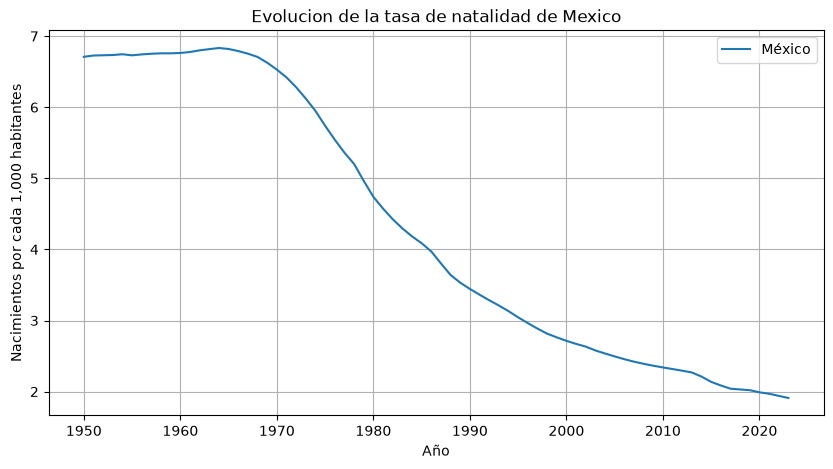

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_mexico, #x
    tasa_mexico,  #y
    label="México"
)

plt.title("Evolucion de la tasa de natalidad de Mexico")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend() #pa ver cual color es mexico

plt.show()

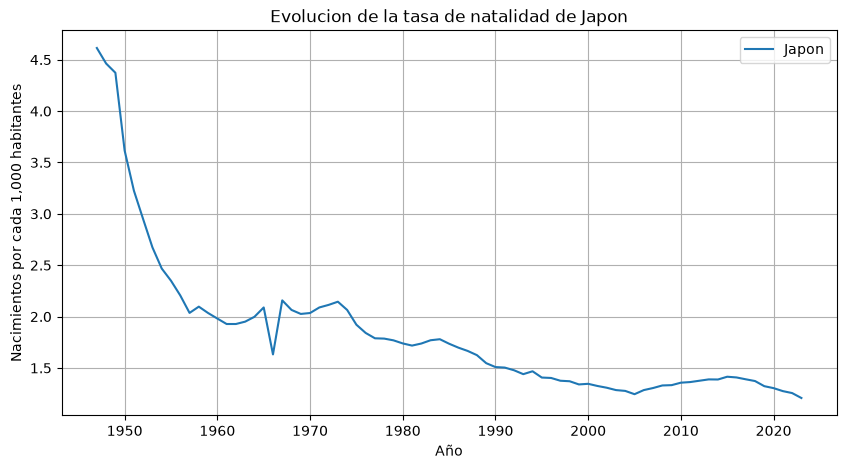

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_japon, #x
    tasa_japon,  #y
    label="Japon"
)

plt.title("Evolucion de la tasa de natalidad de Japon")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend() #pa ver cual color es japon

plt.show()

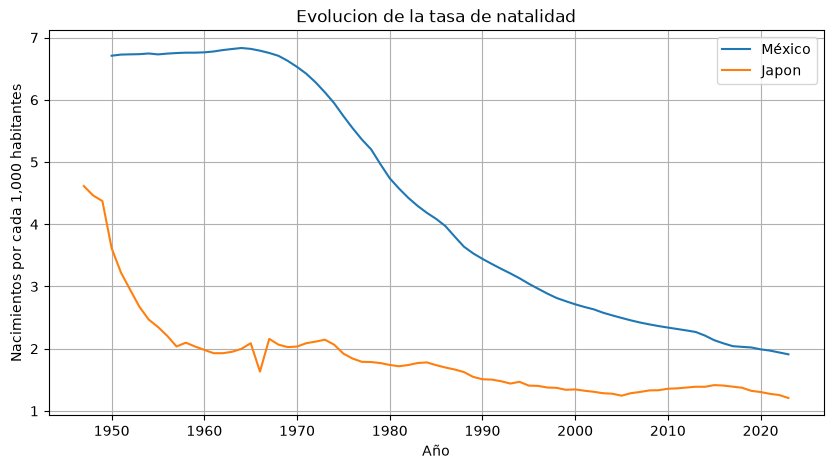

In [ ]:
plt.figure(figsize=(10,5)) #longitud de X y Y
plt.plot(
    anios_mexico, #x
    tasa_mexico,  #y
    label="México"
)

plt.plot(
    anios_japon, #x
    tasa_japon,  #y
    label="Japon"
)

plt.title("Evolucion de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend() #pa ver cual color es mexico y japon

plt.show()

In [55]:
print(mexico.shape)
print(japon.shape)
print(anios_mexico[0])
print(anios_japon[0])

anios_comunes = np.intersect1d(
    anios_mexico,
    anios_japon
)
len(anios_comunes)
#type(anios_comunes)

(74, 4)
(77, 4)
1950
1947


74

In [62]:
#normalizar antes el len para q se pueda
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()
print(mascara_coincidencia_anios)

anios_japon2 = anios_japon[mascara_coincidencia_anios]
tasa_japon2 = tasa_japon[mascara_coincidencia_anios]
print(len(tasa_japon2))
print(len(tasa_mexico))

[False False False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True]
74
74


In [63]:
array = np.array([1,2,3,4,5])
array_suma = array + 10
print(array_suma)

diferencia_mx_jp = tasa_mexico - tasa_japon2
diferencia_mx_jp

[11 12 13 14 15]


array([3.094, 3.502, 3.784, 4.061, 4.277, 4.381, 4.537, 4.716, 4.661,
       4.723, 4.782, 4.849, 4.872, 4.866, 4.835, 4.73 , 5.158, 4.595,
       4.642, 4.6  , 4.494, 4.33 , 4.167, 3.976, 3.882, 3.818, 3.702,
       3.572, 3.416, 3.195, 3.   , 2.856, 2.687, 2.526, 2.404, 2.351,
       2.273, 2.137, 2.015, 1.985, 1.935, 1.859, 1.807, 1.771, 1.664,
       1.637, 1.561, 1.51 , 1.444, 1.423, 1.368, 1.346, 1.325, 1.294,
       1.259, 1.25 , 1.171, 1.116, 1.061, 1.031, 0.983, 0.954, 0.918,
       0.88 , 0.823, 0.722, 0.678, 0.651, 0.657, 0.697, 0.686, 0.695,
       0.684, 0.702])

In [ ]:
#otra forma de normalizar el tamaño
print(anios_japon[30])
print(anios_mexico[30])
print(len(anios_japon))
print(len(anios_mexico))
anios_japon = np.delete(anios_japon, [0,1,2])
print(anios_japon[30])
print(anios_mexico[30])
print(len(anios_japon))
print(len(anios_mexico))

1977
1980
77
74
1980
1980
74
74


In [ ]:
#otra forma de normalizar el tamaño
mexico_anios_comunes = mexico[mexico["year"].isin(anios_comunes)]
japon_anios_comunes = japon[japon["year"].isin(anios_comunes)]
mexico_tasa_comunes = mexico_anios_comunes["fertility_rate_hist"].isin(anios_comunes)
japon_tasa_comunes = japon_anios_comunes["fertility_rate_hist"].isin(anios_comunes)

mexico_anios_comunes2 = mexico_anios_comunes["year"].to_numpy()
japon_anios_comunes2 = japon_anios_comunes["year"].to_numpy()
mexico_tasa_comunes2 = mexico_anios_comunes["fertility_rate_hist"].to_numpy()
japon_tasa_comunes2 = japon_anios_comunes["fertility_rate_hist"].to_numpy()


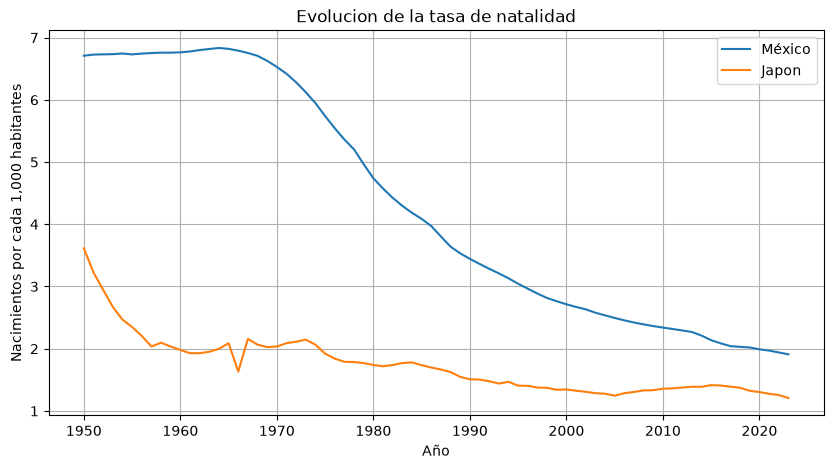

In [81]:
plt.figure(figsize=(10,5)) #longitud de X y Y
plt.plot(
    mexico_anios_comunes2, #x
    mexico_tasa_comunes2,  #y
    label="México"
)

plt.plot(
    japon_anios_comunes2, #x
    japon_tasa_comunes2,  #y
    label="Japon"
)

plt.title("Evolucion de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend() #pa ver cual color es mexico y japon

plt.show()

In [84]:
#otra forma de normalizar el tamaño
comparacion_mexico_japon = pd.merge(
    mexico[["year","fertility_rate_hist"]],
    japon[["year","fertility_rate_hist"]],
    on="year",
    suffixes=("_mexico","_japon")
)
comparacion_mexico_japon.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon
0,1950,6.709,3.615
1,1951,6.727,3.225
2,1952,6.731,2.947


In [85]:
comparacion_mexico_japon["diferencia"]=(
    comparacion_mexico_japon["fertility_rate_hist_mexico"] - comparacion_mexico_japon["fertility_rate_hist_japon"]
)
comparacion_mexico_japon

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon,diferencia
0,1950,6.709,3.615,3.094
1,1951,6.727,3.225,3.502
2,1952,6.731,2.947,3.784
3,1953,6.734,2.673,4.061
4,1954,6.745,2.468,4.277
...,...,...,...,...
69,2019,2.020,1.323,0.697
70,2020,1.990,1.304,0.686
71,2021,1.970,1.275,0.695
72,2022,1.940,1.256,0.684


<Figure size 1000x500 with 0 Axes>

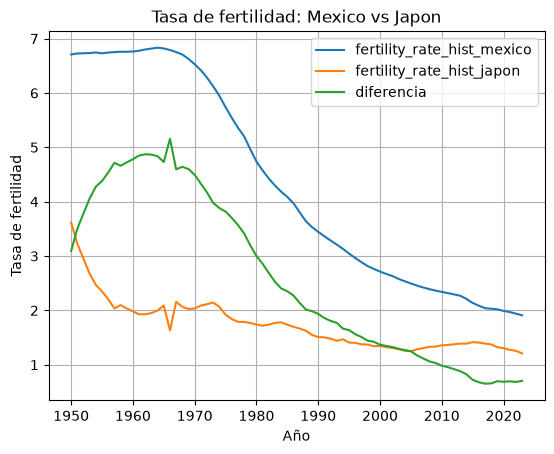

In [88]:
plt.figure(figsize=(10,5)) #longitud de X y Y
comparacion_mexico_japon.plot(
    x="year",
    y=["fertility_rate_hist_mexico","fertility_rate_hist_japon","diferencia"],
    kind="line"
)

plt.title("Tasa de fertilidad: Mexico vs Japon")
plt.xlabel("Año")
plt.ylabel("Tasa de fertilidad")
plt.grid(True)
plt.legend() #pa ver cual color es mexico y japon

plt.show()